# Laboratorio 3: Redes neuronales convolucionales

- Mathew Cordero 22982
- Pedro Guzmán 22111

## Análisis exploratorio

Primero empezaremos haciendo un análisis exploratorio sobre el conjunto de imágenes, obtendremos información de sus dimensiones, cuántas hay, que formatos tienen, etc. 

In [3]:
import os
#import cv2
import pandas as pd
from PIL import Image

def analyze_dataset(base_path):
    data = []

    for subfolder in sorted(os.listdir(base_path)):
        subfolder_path = os.path.join(base_path, subfolder)

        if not os.path.isdir(subfolder_path):
            continue

        for file in os.listdir(subfolder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subfolder_path, file)
                size_kb = os.path.getsize(img_path) / 1024
                with Image.open(img_path) as img:
                    data.append({
                        "Carpeta": subfolder,
                        "Nombre": file,
                        "Formato": img.format,
                        "Ancho": img.width,
                        "Alto": img.height,
                        "Tamaño (KB)": size_kb
                    })
    return pd.DataFrame(data)


In [8]:
test_path = "../archive/PolyMNIST/MMNIST/test"
df_test = analyze_dataset(test_path)

print(f"🔹 Total de imágenes en TEST: {len(df_test)}")
df_test.groupby("Carpeta").size()

df_test

🔹 Total de imágenes en TEST: 50000


,Carpeta,Nombre,Formato,Ancho,Alto,Tamaño (KB)
0,m0,0.0.png,PNG,28,28,2.211914
1,m0,0.1.png,PNG,28,28,1.848633
2,m0,0.2.png,PNG,28,28,2.183594
3,m0,0.3.png,PNG,28,28,1.958008
4,m0,0.4.png,PNG,28,28,2.205078
...,...,...,...,...,...,...
49995,m4,999.1.png,PNG,28,28,1.276367
49996,m4,999.2.png,PNG,28,28,1.264648
49997,m4,999.3.png,PNG,28,28,1.554688
49998,m4,999.7.png,PNG,28,28,1.591797


In [9]:
train_path = "../archive/PolyMNIST/MMNIST/train"
df_train = analyze_dataset(train_path)

print(f"🔹 Total de imágenes en TRAIN: {len(df_train)}")
df_train.groupby("Carpeta").size()

🔹 Total de imágenes en TRAIN: 81444


Carpeta
m0    60000
m1    21444
dtype: int64

Ahora que generamos los datasets, los guardamos como csv

In [10]:
df_test.to_csv('test_images.csv', index=False)
df_train.to_csv('train_images.csv', index=False)

Ahora obtenemos un resumen inicial sobre las característcas iniciales. 

In [11]:
df_test.describe()

,Ancho,Alto,Tamaño (KB)
count,50000.0,50000.0,50000.000000
mean,28.0,28.0,1.444386
std,0.0,0.0,0.387236
min,28.0,28.0,0.275391
25%,28.0,28.0,1.105469
50%,28.0,28.0,1.473633
75%,28.0,28.0,1.771484
max,28.0,28.0,2.318359


Todas las imágenes en el conjunto de prueba tienen las mismas dimensiones, sin embargo su tamaño en kb cambia, esto sugiere que tal vez las imágenes más pesadas tienen más colores y formas más complejas. Ahora veremos una pequeña muestra de las imágenes. 

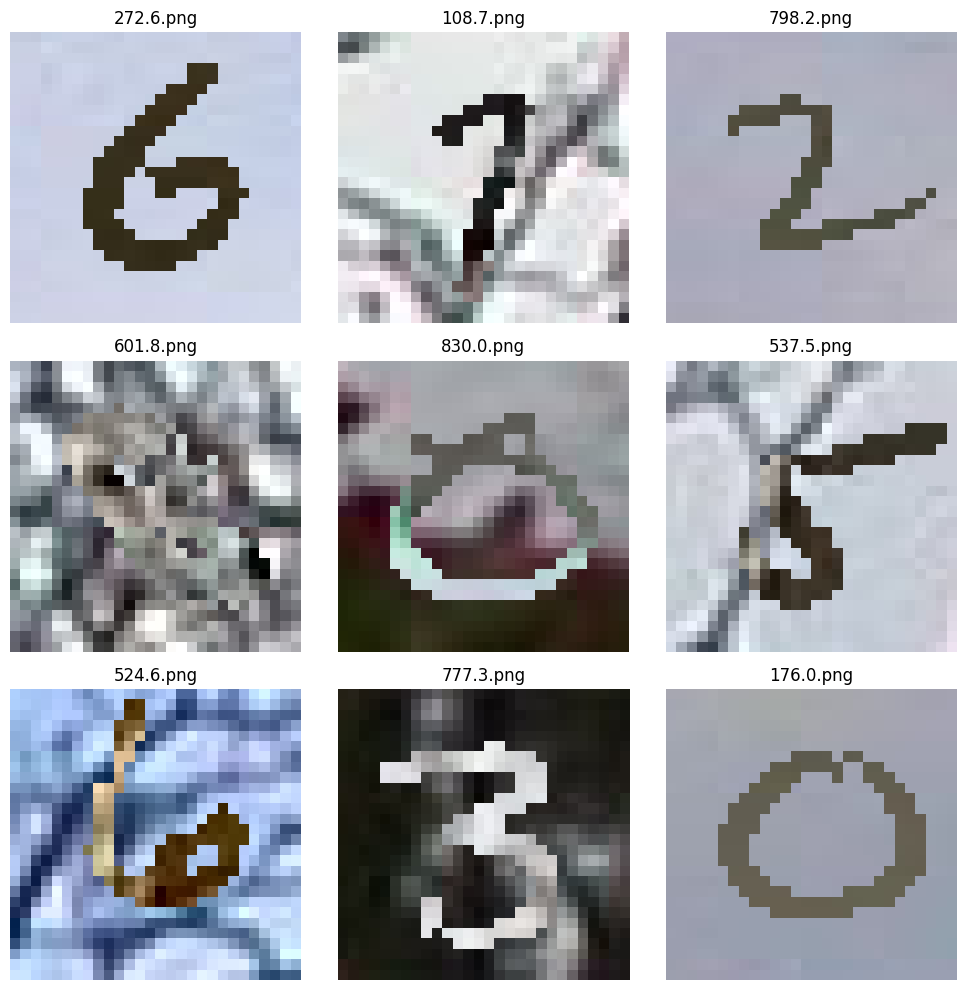

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

folder = "../archive/PolyMNIST/MMNIST/test/m0"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()


Hay imágenes con más resolución que otras, esto confirma la razón de porque no todas tienen el mismo tamaño. Ahora vamos con las de train

In [23]:
df_train.describe()

,Ancho,Alto,Tamaño (KB)
count,81444.0,81444.0,81444.000000
mean,28.0,28.0,1.385750
std,0.0,0.0,0.520434
min,28.0,28.0,0.250000
25%,28.0,28.0,0.944336
50%,28.0,28.0,1.149902
75%,28.0,28.0,1.958984
max,28.0,28.0,2.301758


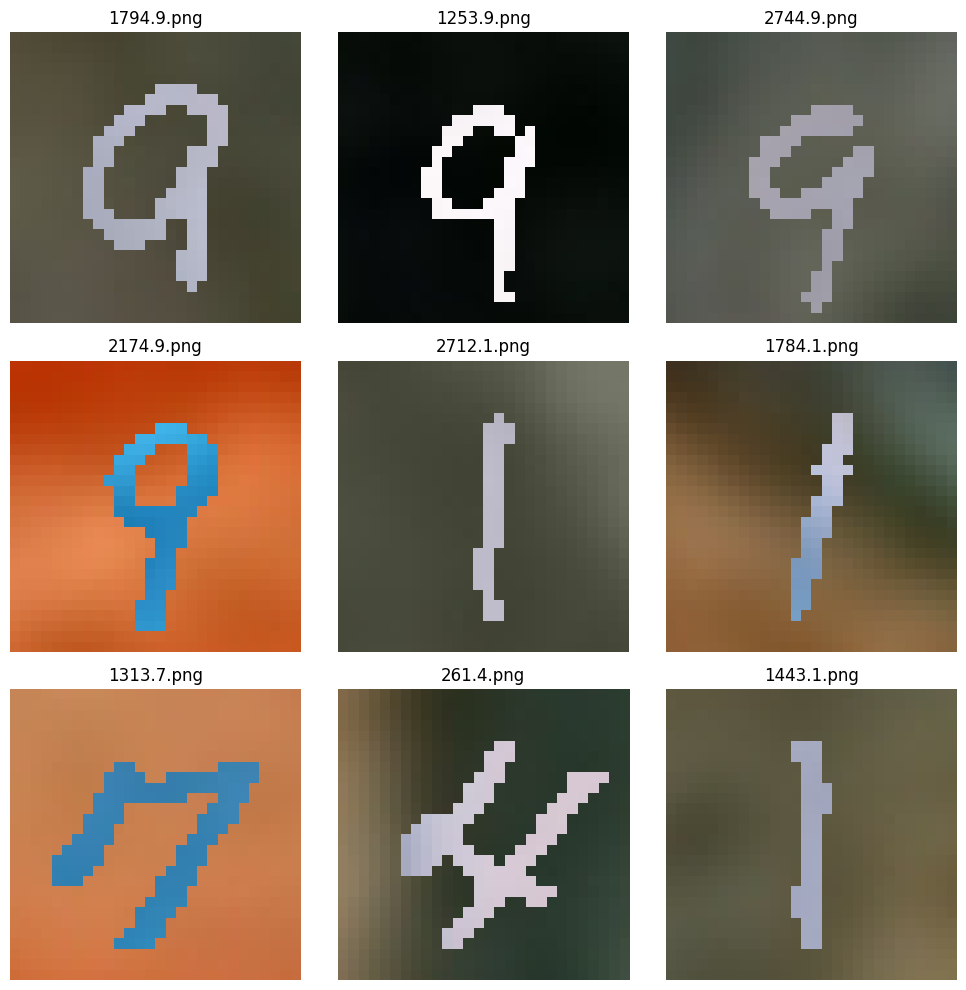

In [24]:
folder = "../archive/PolyMNIST/MMNIST/train/m1"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Transformaciones